# Семинар 3: Функции активации, Dropout, BatchNorm и другие приёмы обучения нейросетей

На этом занятии мы продолжим работать с датасетом AudioMNIST и задачей классификации речевых цифр (10 классов).
Мы уже умеем обучать полносвязные сети на мел-спектрограммах, но качество модели можно значительно улучшить, применяя современные архитектурные приёмы:

- **Нелинейные функции активации** (ReLU, LeakyReLU, ELU, GELU)
- **Регуляризация Dropout**
- **Нормализация по батчам (Batch Normalization)**
- **Планирование скорости обучения (Learning Rate Scheduling)**
- **Weight Decay (L2‑регуляризация)**

Мы будем последовательно добавлять эти компоненты в базовую модель и наблюдать, как меняется динамика обучения и итоговая точность.

## 1. Подготовка данных и базовой модели

Импортируем библиотеки, загружаем AudioMNIST, строим мел-спектрограммы и вычисляем статистики для нормализации признаков.
Этот код вам уже знаком по предыдущему домашнему заданию.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os

from dataset import AudioMNISTDataset

torch.manual_seed(42)
np.random.seed(42)

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# %pip install gdown -q

In [3]:
import gdown
import zipfile

FILE_ID = "13E8JVJdNYS9K9ubdGcruLSMLUD10OLbx"
output = "audio_mnist.zip"

if not os.path.exists(output):
    gdown.download(id=FILE_ID, output=output, quiet=False)

# Распаковка
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(".")

NameError: name 'os' is not defined

In [4]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")

In [5]:
device

device(type='mps')

In [6]:
# Параметры аудио
SAMPLE_RATE = 16000
TARGET_LEN = 16000
N_FFT = 256
HOP_LENGTH = 512

In [7]:
full_dataset = AudioMNISTDataset('data', TARGET_LEN)
train_ratio = 0.8
train_size = int(len(full_dataset) * train_ratio)
val_size = len(full_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Найдено 30000 аудиофайлов


In [8]:
def stft(y, n_fft=int(0.032*SAMPLE_RATE), hop_length=int(0.016*SAMPLE_RATE), win_length=int(0.032*SAMPLE_RATE)):
    """Wrapper of the official torch.stft for single-channel and multi-channel.

    Args:
        y: single- or multi-channel speech with shape of [B, C, T] or [B, T]
        n_fft: number of FFT
        hop_length: hop length
        win_length: hanning window size

    Shapes:
        mag: [B, F, T] if dims of input is [B, T], whereas [B, C, F, T] if dims of input is [B, C, T]

    Returns:
        mag, phase, real and imag with the same shape of [B, F, T] (**complex-valued** STFT coefficients)
    """
    num_dims = y.dim()
    assert num_dims == 2 or num_dims == 3, "Only support 2D or 3D Input"

    batch_size = y.shape[0]
    num_samples = y.shape[-1]

    if num_dims == 3:
        y = y.reshape(-1, num_samples)  # [B * C ,T]

    complex_stft = torch.stft(
        y,
        n_fft,
        hop_length,
        win_length,
        window=torch.hann_window(n_fft, device=y.device),
        return_complex=True,
    )
    _, num_freqs, num_frames = complex_stft.shape

    if num_dims == 3:
        complex_stft = complex_stft.reshape(batch_size, -1, num_freqs, num_frames)

    mag = torch.abs(complex_stft)
    phase = torch.angle(complex_stft)
    real = complex_stft.real
    imag = complex_stft.imag
    return mag, phase, real, imag

In [9]:
INPUT_DIM = 4128

In [10]:
def confusion_matrix(y_true, y_pred, num_classes):
    indices = y_true * num_classes + y_pred
    cm_flat = torch.bincount(indices, minlength=num_classes * num_classes)
    return cm_flat.view(num_classes, num_classes)

def calculate_accuracy(y_true, y_pred):
    return (y_true == y_pred).float().mean().item()

def calculate_precision_recall_f1(y_true, y_pred):
    num_classes = max(y_true.max().item(), y_pred.max().item()) + 1
    cm = confusion_matrix(y_true, y_pred, num_classes).float()
    tp = cm.diag()
    pred_per_class = cm.sum(dim=0)
    true_per_class = cm.sum(dim=1)
    eps = 1e-10

    prec_class = tp / (pred_per_class + eps)
    rec_class = tp / (true_per_class + eps)
    f1_class = 2 * prec_class * rec_class / (prec_class + rec_class + eps)
    precision = prec_class.mean().item()
    recall = rec_class.mean().item()
    f1 = f1_class.mean().item()

    return precision, recall, f1

## 2. Базовая модель с ReLU

Создадим простой MLP с двумя скрытыми слоями и функцией активации **ReLU**:

$$
\text{ReLU}(x) = \max(0, x)
$$

ReLU – самая распространённая активация, не насыщается при положительных значениях и проста в вычислении. Недостаток – «мёртвые нейроны» при отрицательных входах.

In [11]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes):
        super().__init__()
        layers = []

        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dims[0], hidden_dims[1]))
        layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dims[1], num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [13]:
HIDDEN_DIMS = [256, 128]
NUM_CLASSES = 10
LR = 0.01
EPOCHS = 5

baseline_model = BaselineMLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=LR)

In [14]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        mag, phase, real, imag = stft(x, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=N_FFT)
        optimizer.zero_grad()
        logits = model(mag.flatten(start_dim=1))
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        mag, phase, real, imag = stft(x, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=N_FFT)
        logits = model(mag.flatten(start_dim=1))
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    acc = correct / total
    preds_t = torch.cat(all_preds)
    labels_t = torch.cat(all_labels)
    _, _, f1 = calculate_precision_recall_f1(labels_t, preds_t)
    return total_loss / total, acc, f1

In [15]:
history_baseline = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(baseline_model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = eval_epoch(baseline_model, val_loader, criterion)
    history_baseline["train_loss"].append(train_loss)
    history_baseline["val_loss"].append(val_loss)
    history_baseline["val_acc"].append(val_acc)
    history_baseline["val_f1"].append(val_f1)
    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2%} F1: {val_f1:.4f}")

  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.5523 Acc: 83.60% | Val Loss: 0.2713 Acc: 91.45% F1: 0.9153


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

...

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  4 | Train Loss: 0.2099 Acc: 93.73% | Val Loss: 0.2304 Acc: 93.18% F1: 0.9318


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  5 | Train Loss: 0.2111 Acc: 93.97% | Val Loss: 0.4044 Acc: 90.02% F1: 0.9003


## 3. Эксперименты с функциями активации

Рассмотрим альтернативы ReLU.

**LeakyReLU**
$$
f(x) = \begin{cases} x, & x > 0 \\ \alpha x, & x \le 0 \end{cases}
$$
Параметр $\alpha$ (обычно 0.01) задаёт небольшой наклон в отрицательной области, чтобы избежать «мёртвых» нейронов.

**ELU** (Exponential Linear Unit)
$$
f(x) = \begin{cases} x, & x > 0 \\ \alpha (e^x - 1), & x \le 0 \end{cases}
$$
Сглаженная версия, сдвигающая среднюю активацию ближе к нулю, что ускоряет обучение.

Создадим несколько моделей с разными активациями и сравним их кривые обучения.

In [16]:
def create_mlp(activation_name, input_dim, hidden_dims, num_classes):
    layers = []

    prev_dim = input_dim

    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        if activation_name == "relu":
            layers.append(nn.ReLU())
        elif activation_name == "tanh":
            layers.append(nn.Tanh())
        elif activation_name == "sigmoid":
            layers.append(nn.Sigmoid())
        elif activation_name == "elu":
            layers.append(nn.ELU())
        elif activation_name == "leaky_relu":
            layers.append(nn.LeakyReLU())

        prev_dim = hidden_dim

    layers.append(nn.Linear(hidden_dims[-1], num_classes))

    return nn.Sequential(*layers)

In [20]:
model = create_mlp('elu', INPUT_DIM, [256, 128, 64, 32, 16], NUM_CLASSES)
model

Sequential(
  (0): Linear(in_features=4128, out_features=256, bias=True)
  (1): ELU(alpha=1.0)
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ELU(alpha=1.0)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ELU(alpha=1.0)
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ELU(alpha=1.0)
  (8): Linear(in_features=32, out_features=16, bias=True)
  (9): ELU(alpha=1.0)
  (10): Linear(in_features=16, out_features=10, bias=True)
)

In [21]:
activations_to_test = ['leaky_relu', 'sigmoid', 'tanh', 'elu']
histories = {}

for act in activations_to_test:
    print(f"\n=== Обучение модели с активацией: {act.upper()} ===")
    model = create_mlp(act, INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES).to(device)
    opt = optim.SGD(model.parameters(), lr=LR)
    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    for epoch in range(EPOCHS):
        train_loss, _ = train_epoch(model, train_loader, opt, criterion)
        val_loss, val_acc, val_f1 = eval_epoch(model, val_loader, criterion)
        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)
        hist["val_f1"].append(val_f1)
        if epoch % 3 == 0:
            print(f"  Epoch {epoch+1}: Val Acc={val_acc:.2%} F1={val_f1:.4f}")
    histories[act] = hist


=== Обучение модели с активацией: LEAKY_RELU ===


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

  Epoch 1: Val Acc=84.80% F1=0.8457


  0%|          | 0/375 [00:00<?, ?it/s]

...

  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

  Epoch 4: Val Acc=91.90% F1=0.9191


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

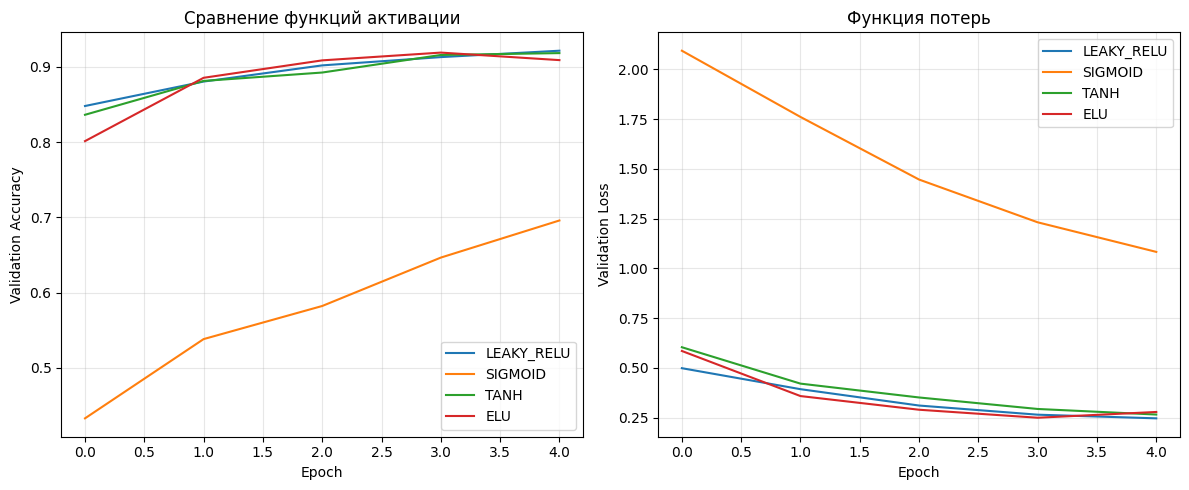

In [22]:
# Визуализация сравнения
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for act in activations_to_test:
    plt.plot(histories[act]["val_acc"], label=act.upper())
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Сравнение функций активации")

plt.subplot(1, 2, 2)
for act in activations_to_test:
    plt.plot(histories[act]["val_loss"], label=act.upper())
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Функция потерь")
plt.tight_layout()
plt.show()

## 4. Dropout – регуляризация от переобучения

**Dropout** случайным образом зануляет выходы нейронов с вероятностью $p$ во время обучения. Это заставляет сеть учиться более робастным признакам и снижает коадаптацию нейронов. На этапе предсказания Dropout отключается, а веса масштабируются на $1-p$ (в PyTorch это происходит автоматически).

Добавим Dropout после каждой функции активации (кроме последнего слоя) и посмотрим, улучшит ли это обобщение.

In [23]:
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout_prob=0.3):
        super().__init__()
        layers = []

        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Tanh())

            if hidden_dim != HIDDEN_DIMS[-1]:
                layers.append(nn.Dropout(dropout_prob))

            prev_dim = hidden_dim

        layers.append(nn.Linear(hidden_dims[-1], num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [25]:
dropout_model = DropoutMLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_prob=0.3).to(device)
opt_drop = optim.SGD(dropout_model.parameters(), lr=LR)
hist_dropout = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(3):
    train_loss, _ = train_epoch(dropout_model, train_loader, opt_drop, criterion)
    val_loss, val_acc, val_f1 = eval_epoch(dropout_model, val_loader, criterion)
    hist_dropout["train_loss"].append(train_loss)
    hist_dropout["val_loss"].append(val_loss)
    hist_dropout["val_acc"].append(val_acc)
    hist_dropout["val_f1"].append(val_f1)
    print(f"Epoch {epoch+1:2d} | Val Acc: {val_acc:.2%} F1: {val_f1:.4f}")

  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1 | Val Acc: 83.87% F1: 0.8389


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  2 | Val Acc: 86.65% F1: 0.8647


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  3 | Val Acc: 88.87% F1: 0.8891


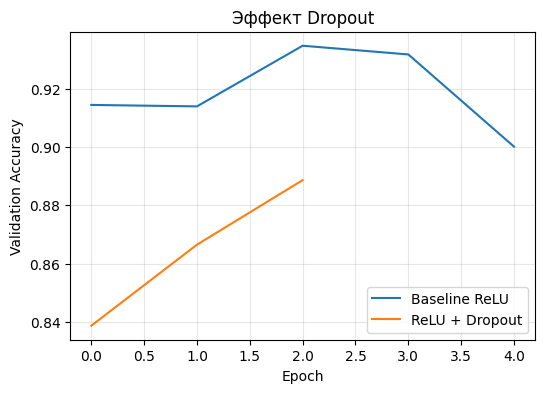

In [26]:
plt.figure(figsize=(6,4))
plt.plot(history_baseline["val_acc"], label="Baseline ReLU")
plt.plot(hist_dropout["val_acc"], label="ReLU + Dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Эффект Dropout")
plt.show()

## 5. Batch Normalization

**Batch Normalization** (BN) нормализует выходы предыдущего слоя по текущему батчу:

$$
\hat{x} = \frac{x - \mu_{\text{batch}}}{\sqrt{\sigma^2_{\text{batch}} + \epsilon}}, \quad y = \gamma \hat{x} + \beta
$$

Это ускоряет обучение, позволяет использовать более высокие скорости обучения и действует как лёгкая регуляризация.

Добавим BN перед каждой активацией.

In [27]:
class BNMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes):
        super().__init__()
        layers = []

        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.Tanh())

            prev_dim = hidden_dim

        layers.append(nn.Linear(hidden_dims[-1], num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [28]:
bn_model = BNMLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES).to(device)
opt_bn = optim.SGD(bn_model.parameters(), lr=LR)  # BN позволяет увеличить lr, но оставим для сравнения
hist_bn = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(3):
    train_loss, _ = train_epoch(bn_model, train_loader, opt_bn, criterion)
    val_loss, val_acc, val_f1 = eval_epoch(bn_model, val_loader, criterion)
    hist_bn["train_loss"].append(train_loss)
    hist_bn["val_loss"].append(val_loss)
    hist_bn["val_acc"].append(val_acc)
    hist_bn["val_f1"].append(val_f1)
    print(f"Epoch {epoch+1:2d} | Val Acc: {val_acc:.2%} F1: {val_f1:.4f}")

  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1 | Val Acc: 87.27% F1: 0.8726


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  2 | Val Acc: 89.20% F1: 0.8922


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  3 | Val Acc: 90.30% F1: 0.9027


## 6. Дополнительные приёмы: Learning Rate Scheduling и Weight Decay

**Learning Rate Scheduling** – изменение скорости обучения во время тренировки. Популярный метод – **StepLR** или **ReduceLROnPlateau**.

**Weight Decay** – добавление к функции потерь штрафа $L_2$ на веса:
$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \sum \|W\|_2^2
$$
В PyTorch задаётся параметром `weight_decay` в оптимизаторе.

Объединим лучшие практики: ReLU + BatchNorm + Dropout + CosineAnnealingLR + Weight Decay.

In [29]:
class BestModel(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout_prob=0.3):
        super().__init__()
        layers = []

        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.Tanh())

            if hidden_dim != HIDDEN_DIMS[-1]:
                layers.append(nn.Dropout(dropout_prob))

            prev_dim = hidden_dim

        layers.append(nn.Linear(hidden_dims[-1], num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [31]:
from torch.optim.lr_scheduler import CosineAnnealingLR

best_model = BestModel(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_prob=0.3).to(device)
optimizer = optim.AdamW(best_model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5)

hist_best = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(EPOCHS):
    train_loss, _ = train_epoch(best_model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = eval_epoch(best_model, val_loader, criterion)
    scheduler.step(train_loss)
    hist_best["train_loss"].append(train_loss)
    hist_best["val_loss"].append(val_loss)
    hist_best["val_acc"].append(val_acc)
    hist_best["val_f1"].append(val_f1)
    print(f"Epoch {epoch+1:2d} | LR: {scheduler.get_last_lr()[0]:.6f} | "
          f"Val Acc: {val_acc:.2%} F1: {val_f1:.4f}")

  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  1 | LR: 0.010000 | Val Acc: 90.37% F1: 0.9041


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

...

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  4 | LR: 0.010000 | Val Acc: 94.62% F1: 0.9460


  0%|          | 0/375 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch  5 | LR: 0.010000 | Val Acc: 94.15% F1: 0.9404


## 7. Сравнение всех подходов

Сведём итоговые кривые точности на валидации для всех рассмотренных вариантов.

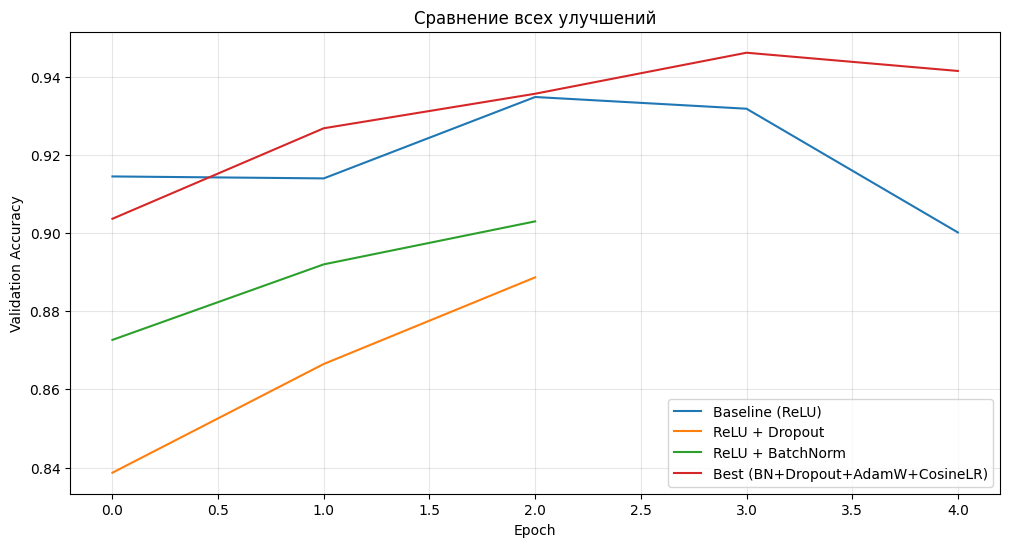

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(history_baseline["val_acc"], label="Baseline (ReLU)")
plt.plot(hist_dropout["val_acc"], label="ReLU + Dropout")
plt.plot(hist_bn["val_acc"], label="ReLU + BatchNorm")
plt.plot(hist_best["val_acc"], label="Best (BN+Dropout+AdamW+CosineLR)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Сравнение всех улучшений")
plt.show()